# Notebook 2 — Residual Value Depreciation Model

**Goal:** Build an OLS log-linear model that predicts a car's market value  
given age, mileage, brand, and fuel type.  
This is the statistical core of the project — exactly what a risk team uses.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette('muted')

df = pd.read_csv('../data/vehicles_clean.csv')
print(f'Loaded: {len(df):,} rows')
df.head(2)

Loaded: 538,704 rows


,year,brand,model,trim,body_type,transmission,vin,state,condition_score,odometer_km,...,selling_price,sale_date,vehicle_age,log_price,log_odometer,is_ev,estimated_new_price,guaranteed_rv,at_risk,risk_exposure
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,...,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST),9,9.975808,9.719565,0,58759.684964,29379.842482,1,7879.842482
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,...,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST),9,9.975808,9.147826,0,58759.684964,29379.842482,1,7879.842482


## 1. OLS Log-Linear Depreciation Model

In [2]:
# ── Prepare modelling dataset ─────────────────────────────────────────────────
model_cols = ['log_price', 'vehicle_age', 'log_odometer', 'is_ev']
if 'brand' in df.columns:
    model_cols.append('brand')
if 'condition_score' in df.columns:
    model_cols.append('condition_score')

df_model = df[model_cols].dropna()

# Keep top 20 brands by volume to avoid sparse dummies
if 'brand' in df_model.columns:
    top_brands = df_model['brand'].value_counts().head(20).index
    df_model = df_model[df_model['brand'].isin(top_brands)]
    df_model['brand'] = df_model['brand'].str.title()  # capitalise for display

print(f'Modelling dataset: {len(df_model):,} rows')

Modelling dataset: 471,338 rows


In [3]:
# ── OLS formula ───────────────────────────────────────────────────────────────
# log(price) ~ age + log(odometer) + EV flag + brand dummies
# Coefficients are % change in price per unit — directly interpretable

formula_parts = ['log_price ~ vehicle_age + log_odometer + is_ev']
if 'brand' in df_model.columns:
    formula_parts.append('C(brand)')
if 'condition_score' in df_model.columns:
    formula_parts.append('condition_score')

formula = formula_parts[0] + ' + ' + ' + '.join(formula_parts[1:]) if len(formula_parts) > 1 else formula_parts[0]

ols_model = smf.ols(formula, data=df_model).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                 4.282e+04
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:08:03   Log-Likelihood:            -2.5366e+05
No. Observations:              471338   AIC:                         5.074e+05
Df Residuals:                  471314   BIC:                         5.076e+05
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [4]:
# ── Key coefficient interpretation ────────────────────────────────────────────
coef = ols_model.params

age_effect     = (np.exp(coef.get('vehicle_age', 0)) - 1) * 100
odo_effect     = (np.exp(coef.get('log_odometer', 0)) - 1) * 100
ev_effect      = (np.exp(coef.get('is_ev', 0)) - 1) * 100

print('=== Depreciation Drivers ===')
print(f'Each additional year of age:   {age_effect:+.1f}% change in price')
print(f'EV premium/discount vs ICE:    {ev_effect:+.1f}%')
print(f'\nModel R²: {ols_model.rsquared:.3f}')
print(f'Adj. R²:  {ols_model.rsquared_adj:.3f}')

=== Depreciation Drivers ===
Each additional year of age:   -13.3% change in price
EV premium/discount vs ICE:    -30.0%

Model R²: 0.676
Adj. R²:  0.676


In [5]:
# ── Prediction & residuals ────────────────────────────────────────────────────
df_model['log_price_pred'] = ols_model.fittedvalues
df_model['price_pred']     = np.exp(df_model['log_price_pred'])
df_model['price_actual']   = np.exp(df_model['log_price'])
df_model['residual']       = df_model['price_actual'] - df_model['price_pred']

mae = mean_absolute_error(df_model['price_actual'], df_model['price_pred'])
r2  = r2_score(df_model['price_actual'], df_model['price_pred'])

print(f'MAE: €{mae:,.0f}')
print(f'R²:  {r2:.3f}')

MAE: €4,060
R²:  0.551


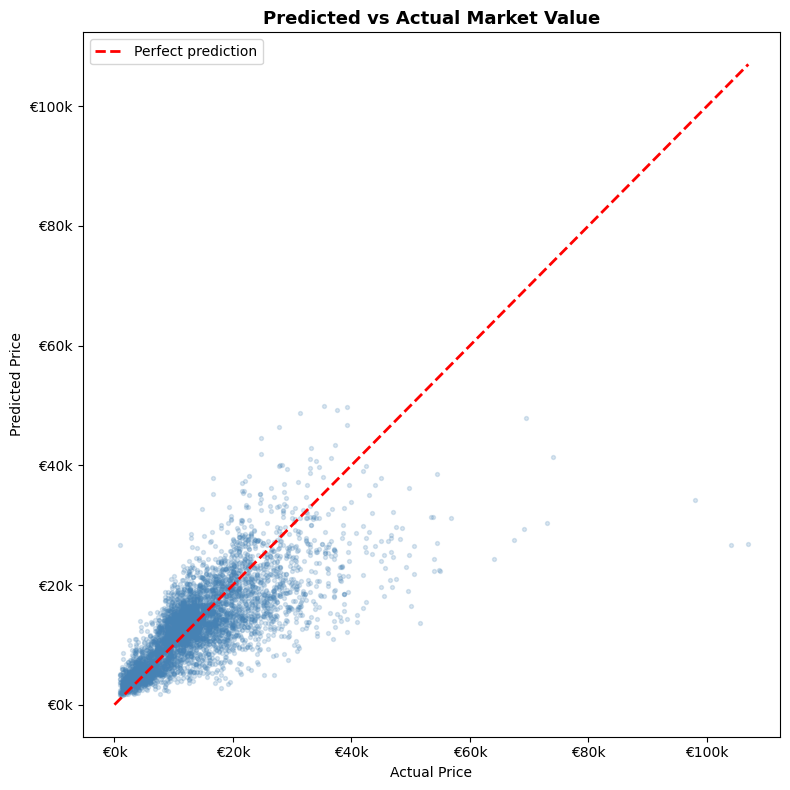

💾 Saved: outputs/04_predicted_vs_actual.png


In [6]:
# ── Plot 1: Predicted vs Actual ───────────────────────────────────────────────
sample = df_model.sample(min(5000, len(df_model)), random_state=42)

plt.figure(figsize=(8, 8))
plt.scatter(sample['price_actual'], sample['price_pred'], 
            alpha=0.2, s=8, color='steelblue')
max_val = max(sample['price_actual'].max(), sample['price_pred'].max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
plt.title('Predicted vs Actual Market Value', fontweight='bold', fontsize=13)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/04_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: outputs/04_predicted_vs_actual.png')

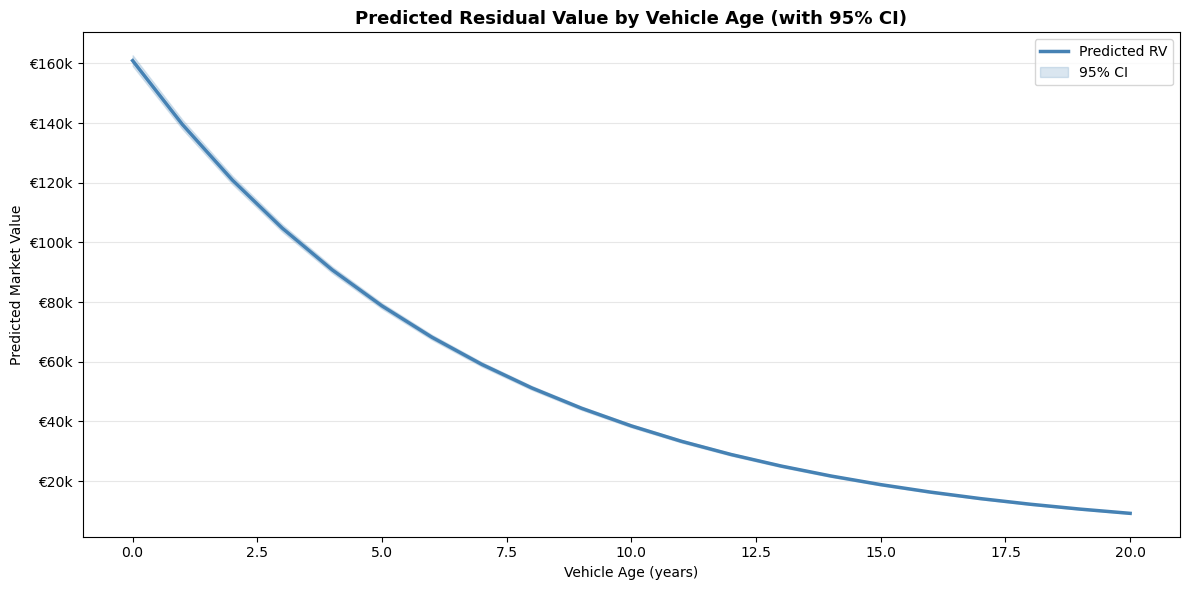

💾 Saved: outputs/05_rv_with_confidence_band.png


In [7]:
# ── Plot 2: Depreciation curve with confidence band ───────────────────────────
# Generate predictions across vehicle ages with 95% CI
pred_data = pd.DataFrame({
    'vehicle_age':    range(0, 21),
    'log_odometer':   np.log1p(df_model['log_odometer'].mean()),
    'is_ev':          0,
})
if 'condition_score' in df_model.columns:
    pred_data['condition_score'] = df_model['condition_score'].mean()
if 'brand' in df_model.columns:
    pred_data['brand'] = df_model['brand'].mode()[0]

pred_result = ols_model.get_prediction(pred_data)
pred_summary = pred_result.summary_frame(alpha=0.05)

ages      = pred_data['vehicle_age']
mean_pred = np.exp(pred_summary['mean'])
ci_lower  = np.exp(pred_summary['mean_ci_lower'])
ci_upper  = np.exp(pred_summary['mean_ci_upper'])

plt.figure(figsize=(12, 6))
plt.plot(ages, mean_pred, linewidth=2.5, color='steelblue', label='Predicted RV')
plt.fill_between(ages, ci_lower, ci_upper, alpha=0.2, color='steelblue', label='95% CI')
plt.title('Predicted Residual Value by Vehicle Age (with 95% CI)', fontweight='bold', fontsize=13)
plt.xlabel('Vehicle Age (years)')
plt.ylabel('Predicted Market Value')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/05_rv_with_confidence_band.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: outputs/05_rv_with_confidence_band.png')

In [8]:
# ── Save predictions back to data ─────────────────────────────────────────────
df_model.to_csv('../data/vehicles_with_predictions.csv', index=False)
print('✅ Saved: data/vehicles_with_predictions.csv')
print('\n→ Next: open 03_risk_classification.ipynb')

✅ Saved: data/vehicles_with_predictions.csv

→ Next: open 03_risk_classification.ipynb
